<a href="https://colab.research.google.com/github/St1CkBSPL/PF174712/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.9 MB/s eta 0:00:00
Ładowanie modelu GloVe...
[==================================================] 100.0% 128.1/128.1MB downloaded

1. Kształt wektora 'university': (100,)
Pierwsze 10 wartości: [ 0.6958  -0.19334 -0.78134 -0.45589  0.29245  0.36482  0.42036  0.39444
 -0.82601  0.95148]

2. Najbliżsi sąsiedzi:
science: ['sciences', 'physics', 'institute', 'mathematics', 'studies', 'research', 'biology', 'university', 'psychology', 'economics']
music: ['musical', 'songs', 'dance', 'pop', 'recording', 'folk', 'jazz', 'concert', 'artists', 'song']
football: ['soccer', 'basketball', 'league', 'rugby', 'hockey', 'club', 'team', 'baseball', 'players', 'player']

3. Podobieństwo cosinusowe:
doctor - nurse: 0.7522
doctor - airplane: 0.2222
happy - sad: 0.6801
happy - joyful: 0.5260

4. Co nie pasuje?
Grupa ['apple', 'banana', 'orange', 'car']: Nie pasuje -> car
Grupa ['dog', 'cat', 'mouse', 'table']: Nie pasuje -> table

5. Analogie:
ja

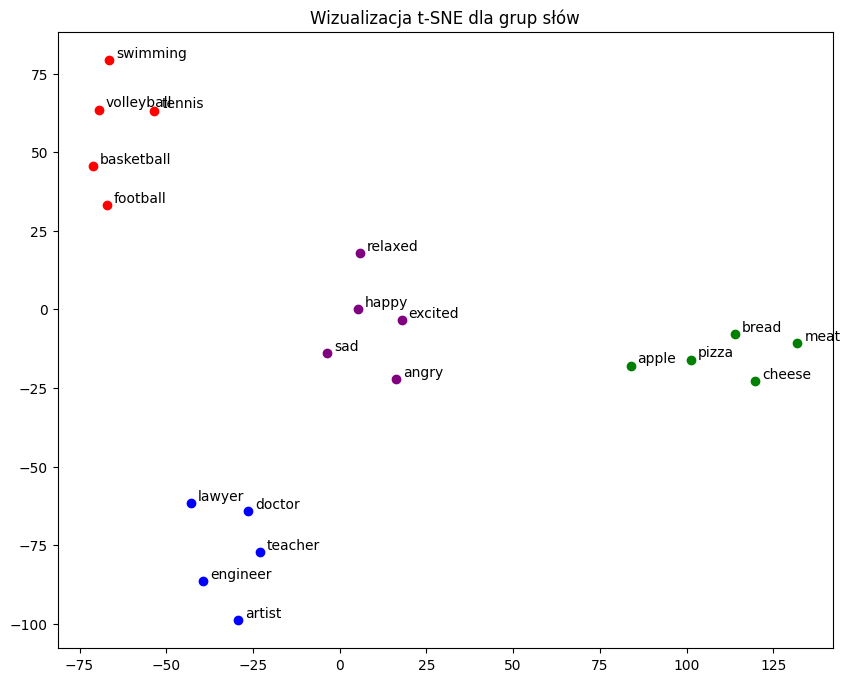

In [ ]:
!pip install gensim
import gensim.downloader as api
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

model = api.load("glove-wiki-gigaword-100")

# KROK 1: Wektor dla słowa "university"
vec = model["university"]
print(f"\n1. Kształt wektora 'university': {vec.shape}")
print(f"Pierwsze 10 wartości: {vec[:10]}")

# KROK 2: 10 najbliższych sąsiadów
words_to_check = ["science", "music", "football"]
print("\n2. Najbliżsi sąsiedzi:")
for word in words_to_check:
    neighbors = model.most_similar(word, topn=10)
    print(f"{word}: {[n[0] for n in neighbors]}")

# KROK 3: Podobieństwo cosinusowe
pairs = [("doctor", "nurse"), ("doctor", "airplane"), ("happy", "sad"), ("happy", "joyful")]
print("\n3. Podobieństwo cosinusowe:")
for w1, w2 in pairs:
    sim = model.similarity(w1, w2)
    print(f"{w1} - {w2}: {sim:.4f}")

# KROK 4: Metoda doesnt_match
groups = [
    ["apple", "banana", "orange", "car"],
    ["dog", "cat", "mouse", "table"]
]
print("\n4. Co nie pasuje?")
for group in groups:
    print(f"Grupa {group}: Nie pasuje -> {model.doesnt_match(group)}")

# KROK 5: Analogie wektorowe
print("\n5. Analogie:")
# Japan - Tokyo + Paris = ? (Kraj - Stolica + Stolica)
result1 = model.most_similar(positive=['japan', 'paris'], negative=['tokyo'], topn=1)
# Teacher - School + Hospital = ? (Zawód - Miejsce + Miejsce)
result2 = model.most_similar(positive=['teacher', 'hospital'], negative=['school'], topn=1)
# Slow - Slower + Faster = ? (Przymiotnik - Stopień wyższy + Stopień wyższy)
result3 = model.most_similar(positive=['slow', 'faster'], negative=['slower'], topn=1)

print(f"japan - tokyo + paris = {result1[0][0]}")
print(f"teacher - school + hospital = {result2[0][0]}")
print(f"slow - slower + faster = {result3[0][0]}")

# KROK 6: Wizualizacja t-SNE
groups_viz = {
    "sporty": ["football", "basketball", "tennis", "swimming", "volleyball"],
    "zawody": ["doctor", "teacher", "engineer", "lawyer", "artist"],
    "jedzenie": ["pizza", "bread", "cheese", "apple", "meat"],
    "emocje": ["happy", "sad", "angry", "excited", "relaxed"]
}

all_words = []
labels = []
for category, words in groups_viz.items():
    all_words.extend(words)
    labels.extend([category] * len(words))

word_vectors = np.array([model[w] for w in all_words])

# Redukcja wymiarów do 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectors_2d = tsne.fit_transform(word_vectors)

plt.figure(figsize=(10, 8))
colors = {'sporty': 'red', 'zawody': 'blue', 'jedzenie': 'green', 'emocje': 'purple'}

for i, word in enumerate(all_words):
    plt.scatter(vectors_2d[i, 0], vectors_2d[i, 1], c=colors[labels[i]])
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.title("Wizualizacja t-SNE dla grup słów")
plt.show()